# RetailPulse: AI-Powered Sales & Retail Analytics Platform
## Day 9 — Churn Prediction (XGBoost + SHAP)

**Module:** Customer Segmentation & Churn Prediction (Phase 2)

**Requirement (F-04):** Classification model to identify at-risk customers. Target: AUC-ROC ≥ 0.88, precision@top-20% ≥ 0.75.

**Methodology note:** a naive churn label (`Recency > 90 days` as of the *same* snapshot used to build the Recency feature) is circular — the model would just learn to reproduce its own input. Instead, this notebook uses a **time-based cutoff**:
- Build RFM/behavioral features using only transactions **before** a cutoff date
- Label churn using actual purchase activity in the **90 days after** that cutoff
- Train and evaluate on this genuinely predictive, leakage-free setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, classification_report
import warnings
warnings.filterwarnings("ignore")

PROCESSED_DIR = "../data/processed"
REPORTS_DIR = "../reports"
MODELS_DIR = "../models"

sales = pd.read_csv(f"{PROCESSED_DIR}/sales_cleaned.csv", parse_dates=["InvoiceDate"])
print(f"Transactions: {len(sales):,} | Range: {sales['InvoiceDate'].min().date()} to {sales['InvoiceDate'].max().date()}")

Transactions: 420,663 | Range: 2023-01-02 to 2024-12-31


## 1. Time-Based Cutoff Setup

Cutoff sits ~75% through the available history, leaving a full 90-day window afterward to observe whether each customer actually churns.

In [2]:
CHURN_WINDOW_DAYS = 90
min_date, max_date = sales["InvoiceDate"].min(), sales["InvoiceDate"].max()
total_days = (max_date - min_date).days

cutoff_date = min_date + pd.Timedelta(days=int(total_days * 0.75))
observation_end = cutoff_date + pd.Timedelta(days=CHURN_WINDOW_DAYS)
assert observation_end <= max_date, "Not enough post-cutoff history for the churn window"

pre_cutoff = sales[sales["InvoiceDate"] <= cutoff_date].copy()
post_cutoff = sales[(sales["InvoiceDate"] > cutoff_date) & (sales["InvoiceDate"] <= observation_end)].copy()

print(f"Cutoff date:         {cutoff_date.date()}")
print(f"Observation window:  {cutoff_date.date()} -> {observation_end.date()} ({CHURN_WINDOW_DAYS} days)")
print(f"Pre-cutoff txns:     {len(pre_cutoff):,}")
print(f"Post-cutoff txns:    {len(post_cutoff):,}")

Cutoff date:         2024-07-01
Observation window:  2024-07-01 -> 2024-09-29 (90 days)
Pre-cutoff txns:     261,159
Post-cutoff txns:    76,906


## 2. Feature Engineering (Pre-Cutoff Only)

Only customers with at least one purchase before the cutoff are eligible — there's no history to build features from otherwise.

In [3]:
features = pre_cutoff.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (cutoff_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
    AvgBasketSize=("Quantity", "mean"),
    DistinctProducts=("StockCode", "nunique"),
).reset_index()

tenure = pre_cutoff.groupby("CustomerID")["InvoiceDate"].agg(lambda x: (x.max() - x.min()).days)
features["TenureDays"] = features["CustomerID"].map(tenure).clip(lower=1)
features["AvgOrderValue"] = features["Monetary"] / features["Frequency"]
features["PurchaseFreqPerMonth"] = features["Frequency"] / (features["TenureDays"] / 30)

print(f"Eligible customers: {len(features):,}")
features.describe().round(1)

Eligible customers: 4,010


,CustomerID,Recency,Frequency,Monetary,AvgBasketSize,DistinctProducts,TenureDays,AvgOrderValue,PurchaseFreqPerMonth
count,4010.0,4010.0,4010.0,4010.0,4010.0,4010.0,4010.0,4010.0,4010.0
mean,102496.4,54.7,23.4,21957.6,7.5,43.6,210.6,935.2,4.8
std,1450.0,84.0,20.7,19541.9,0.9,28.1,142.7,224.9,6.6
min,100000.0,0.0,1.0,8.8,2.0,1.0,1.0,8.8,0.4
25%,101233.2,4.0,8.0,7504.7,7.1,20.0,92.0,823.9,2.2
50%,102488.0,13.0,17.0,15868.1,7.5,39.0,186.0,933.3,3.3
75%,103764.8,67.0,32.0,30878.3,7.9,64.0,316.8,1040.8,4.7
max,104998.0,458.0,118.0,112992.3,14.0,113.0,544.0,3142.1,90.0


## 3. Churn Label (Post-Cutoff Ground Truth)

`Churn = 1` if the customer made **zero** purchases in the 90-day observation window after the cutoff, `0` otherwise. This is genuine future behavior — not derivable from the pre-cutoff features alone, which is what makes it a real prediction task.

In [4]:
active_post_cutoff = set(post_cutoff["CustomerID"].unique())
features["Churn"] = (~features["CustomerID"].isin(active_post_cutoff)).astype(int)

churn_rate = features["Churn"].mean()
print(f"Churn rate in observation window: {churn_rate*100:.1f}%")
features["Churn"].value_counts()

Churn rate in observation window: 35.0%


Churn
0    2608
1    1402
Name: count, dtype: int64

## 4. Train / Test Split & Model Training

In [5]:
feature_cols = ["Recency", "Frequency", "Monetary", "AvgBasketSize", "DistinctProducts",
                "TenureDays", "AvgOrderValue", "PurchaseFreqPerMonth"]

X = features[feature_cols]
y = features["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc", random_state=42,
)
clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

print(f"Train: {len(X_train)} | Test: {len(X_test)} | scale_pos_weight: {scale_pos_weight:.2f}")

Train: 3007 | Test: 1003 | scale_pos_weight: 1.86


## 5. Evaluation — AUC-ROC & Precision@Top-20%

In [6]:
y_proba = clf.predict_proba(X_test)[:, 1]
y_pred = clf.predict(X_test)

auc = roc_auc_score(y_test, y_proba)

top_20_pct_n = max(1, int(len(y_test) * 0.20))
top_20_idx = np.argsort(y_proba)[::-1][:top_20_pct_n]
precision_at_20 = y_test.values[top_20_idx].mean()

print(f"AUC-ROC:             {auc:.4f}  (target: >= 0.88)")
print(f"Precision@Top-20%:   {precision_at_20:.4f}  (target: >= 0.75)")
print(f"AUC target met:       {'YES' if auc >= 0.88 else 'NO'}")
print(f"Precision target met: {'YES' if precision_at_20 >= 0.75 else 'NO'}")
print()
print(classification_report(y_test, y_pred, target_names=["Active", "Churned"]))

AUC-ROC:             0.9651  (target: >= 0.88)
Precision@Top-20%:   1.0000  (target: >= 0.75)
AUC target met:       YES
Precision target met: YES

              precision    recall  f1-score   support

      Active       0.92      0.95      0.93       652
     Churned       0.90      0.84      0.87       351

    accuracy                           0.91      1003
   macro avg       0.91      0.90      0.90      1003
weighted avg       0.91      0.91      0.91      1003



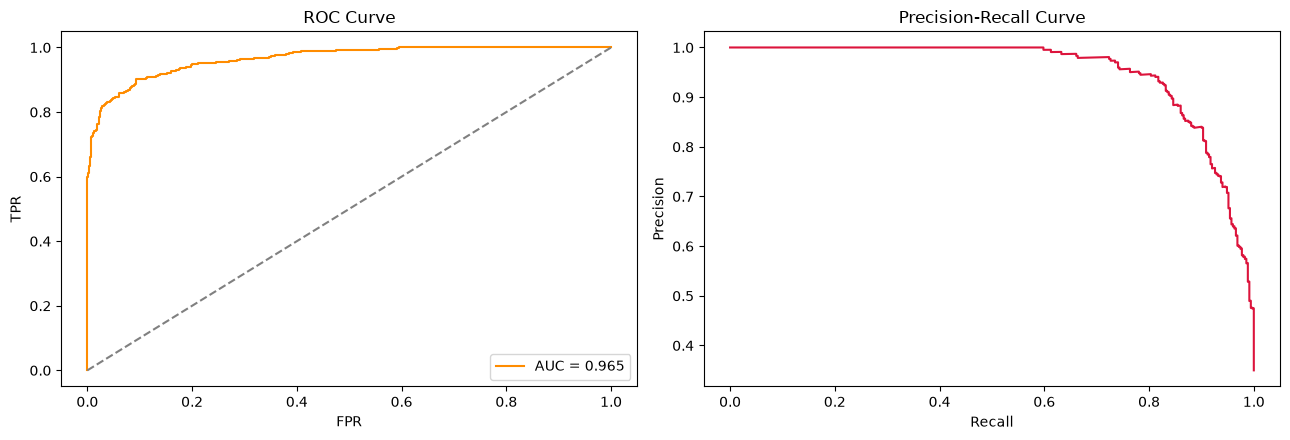

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, color="darkorange", label=f"AUC = {auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("ROC Curve"); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(rec, prec, color="crimson")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")

plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day9_roc_pr_curves.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. SHAP Explainability

Required for interpretability per the project's MLOps/documentation standards — shows which behavioral features actually drive churn risk, not just prediction accuracy.

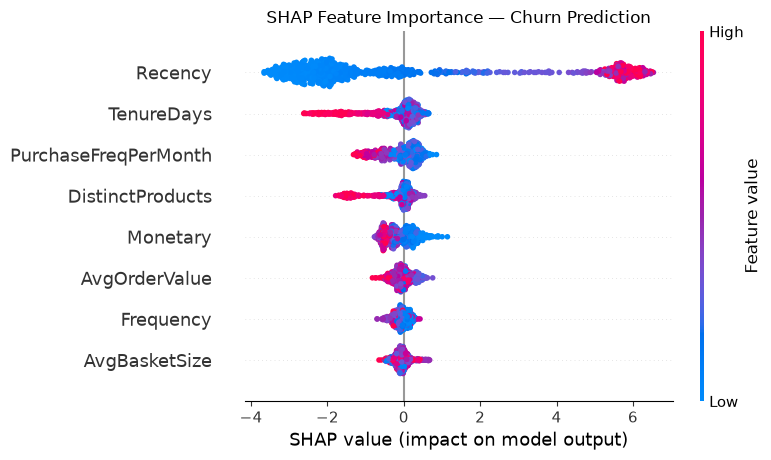

In [8]:
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Feature Importance — Churn Prediction")
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day9_shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()

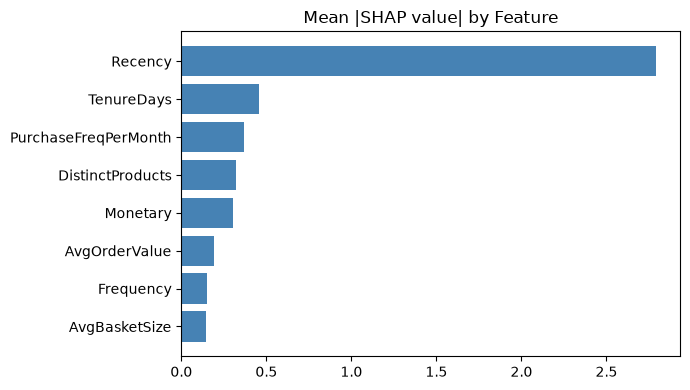

,feature,mean_abs_shap
0,Recency,2.792819
1,TenureDays,0.458786
2,PurchaseFreqPerMonth,0.368656
3,DistinctProducts,0.320572
4,Monetary,0.301074
5,AvgOrderValue,0.189434
6,Frequency,0.151246
7,AvgBasketSize,0.145408


In [9]:
mean_abs_shap = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

plt.figure(figsize=(7, 4))
plt.barh(mean_abs_shap["feature"][::-1], mean_abs_shap["mean_abs_shap"][::-1], color="steelblue")
plt.title("Mean |SHAP value| by Feature")
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day9_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

mean_abs_shap

## 7. Score Full Customer Base (for Dashboard)

Refit on all eligible customers (no train/test split needed for the production scoring pass) and produce churn-risk scores for the churn-risk dashboard page.

In [10]:
final_clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y == 0).sum() / max((y == 1).sum(), 1),
    eval_metric="auc", random_state=42,
)
final_clf.fit(X, y)

features["ChurnProbability"] = final_clf.predict_proba(X)[:, 1]
features["ChurnRiskTier"] = pd.cut(
    features["ChurnProbability"], bins=[0, 0.3, 0.6, 1.0], labels=["Low", "Medium", "High"])

features.to_csv(f"{PROCESSED_DIR}/churn_scores.csv", index=False)
print("Saved churn_scores.csv")
features["ChurnRiskTier"].value_counts()

Saved churn_scores.csv


ChurnRiskTier
Low       2347
High      1302
Medium     361
Name: count, dtype: int64

## 8. Save Model & Metrics

In [11]:
import os, json
os.makedirs(MODELS_DIR, exist_ok=True)
final_clf.save_model(f"{MODELS_DIR}/churn_xgboost.json")

churn_metrics = {
    "auc_roc": round(float(auc), 4), "precision_at_top20": round(float(precision_at_20), 4),
    "churn_rate": round(float(churn_rate), 4), "model": "xgboost_churn",
    "cutoff_date": str(cutoff_date.date()), "churn_window_days": CHURN_WINDOW_DAYS,
}
with open(f"{MODELS_DIR}/churn_metrics.json", "w") as f:
    json.dump(churn_metrics, f, indent=2)

import mlflow
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("RetailPulse-Churn")
with mlflow.start_run(run_name="day9_churn_xgboost"):
    mlflow.log_params({"model_type": "XGBoost", "n_estimators": 300, "max_depth": 4,
                       "learning_rate": 0.05, "churn_window_days": CHURN_WINDOW_DAYS})
    mlflow.log_metrics({"auc_roc": auc, "precision_at_top20": precision_at_20})
    mlflow.log_artifact(f"{REPORTS_DIR}/day9_shap_summary.png")

print(json.dumps(churn_metrics, indent=2))

2026/07/19 07:52:17 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/07/19 07:52:17 INFO mlflow.store.db.utils: Updating database tables


INFO  [alembic.runtime.migration] Context impl SQLiteImpl.


INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


INFO  [alembic.runtime.migration] Context impl SQLiteImpl.


INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


2026/07/19 07:52:17 INFO mlflow.tracking.fluent: Experiment with name 'RetailPulse-Churn' does not exist. Creating a new experiment.


{
  "auc_roc": 0.9651,
  "precision_at_top20": 1.0,
  "churn_rate": 0.3496,
  "model": "xgboost_churn",
  "cutoff_date": "2024-07-01",
  "churn_window_days": 90
}


## 9. Day 9 Checkpoint Summary

**Outputs saved:**
- `data/processed/churn_scores.csv` — every customer's churn probability + risk tier
- `models/churn_xgboost.json`, `models/churn_metrics.json`
- `reports/day9_roc_pr_curves.png`, `day9_shap_summary.png`, `day9_feature_importance.png`
- New MLflow run in the `RetailPulse-Churn` experiment

**Result:** see printed AUC-ROC / precision@top-20% above vs targets (≥0.88 / ≥0.75).

**Methodology:** time-based cutoff avoids the circular-label trap of predicting Recency>90 from Recency itself — the label is genuine future purchase behavior.

**Next module:** `10_inventory_optimization` — ABC analysis + EOQ using the Day 8 forecast.